# Exploratory Data Analysis - Train Companies Dataset
This notebook explores the structured company-level features in `train_companies.csv`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


## Loading the Dataset


In [2]:
df = pd.read_csv('../data/train_companies.csv')
print(f'Dataset shape: {df.shape}')
df.head()


Dataset shape: (1000, 12)


,company_id,company_name,sector,country,revenue_m,ebitda_margin,debt_ratio,interest_coverage,cash_ratio,years_in_operation,employee_count,revenue_growth
0,1,Aster Holdings #0001,Retail,Ireland,28.640542,0.145569,0.338206,1.442259,0.045631,12,65,0.122521
1,2,BluePeak Solutions #0002,Hospitality,Netherlands,58.638440,0.128477,0.663768,1.996529,0.076697,13,284,-0.022019
2,3,Crestline Partners #0003,Real Estate,Spain,42.623014,0.189827,0.416103,1.454863,0.103584,20,205,0.219222
3,4,Dune Finance #0004,Logistics,Luxembourg,36.909677,0.138208,0.543366,0.767183,0.082876,14,153,0.067573
4,5,Evergreen Holdings #0005,Logistics,Germany,40.088725,0.134665,0.413604,3.085223,0.033460,13,226,0.106085


## Data Quality & Missing Values


In [3]:
df.info()
missing = df.isnull().sum()
print('\nMissing values per column:')
print(missing[missing > 0] if missing.any() else 'No missing values.')


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   company_id          1000 non-null   int64  
 1   company_name        1000 non-null   str    
 2   sector              1000 non-null   str    
 3   country             1000 non-null   str    
 4   revenue_m           1000 non-null   float64
 5   ebitda_margin       1000 non-null   float64
 6   debt_ratio          1000 non-null   float64
 7   interest_coverage   1000 non-null   float64
 8   cash_ratio          1000 non-null   float64
 9   years_in_operation  1000 non-null   int64  
 10  employee_count      1000 non-null   int64  
 11  revenue_growth      1000 non-null   float64
dtypes: float64(6), int64(3), str(3)
memory usage: 133.9 KB

Missing values per column:
No missing values.


## Duplicate Check


In [4]:
duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')
unique_companies = df['company_id'].nunique()
print(f'Unique company IDs: {unique_companies} (out of {len(df)} rows)')


Number of duplicate rows: 0
Unique company IDs: 1000 (out of 1000 rows)


## Numerical Features Summary Statistics


In [5]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'company_id' in num_cols: num_cols.remove('company_id')
df[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
revenue_m,1000.0,40.806909,17.796211,6.000000,28.855424,41.295799,53.065257,94.456404
ebitda_margin,1000.0,0.151258,0.050338,0.020000,0.116932,0.151950,0.184980,0.302977
debt_ratio,1000.0,0.422025,0.118141,0.090068,0.339629,0.420738,0.500190,0.790621
interest_coverage,1000.0,2.784211,1.257096,0.200000,1.903531,2.766037,3.563915,7.290260
cash_ratio,1000.0,0.092359,0.039683,0.010000,0.064375,0.092481,0.118962,0.219650
years_in_operation,1000.0,12.079000,5.041049,1.000000,9.000000,12.000000,16.000000,28.000000
employee_count,1000.0,137.673000,57.438622,18.000000,99.000000,135.000000,176.000000,338.000000
revenue_growth,1000.0,0.063378,0.099192,-0.250000,0.000055,0.064596,0.129757,0.350000


## Numerical Feature Distributions


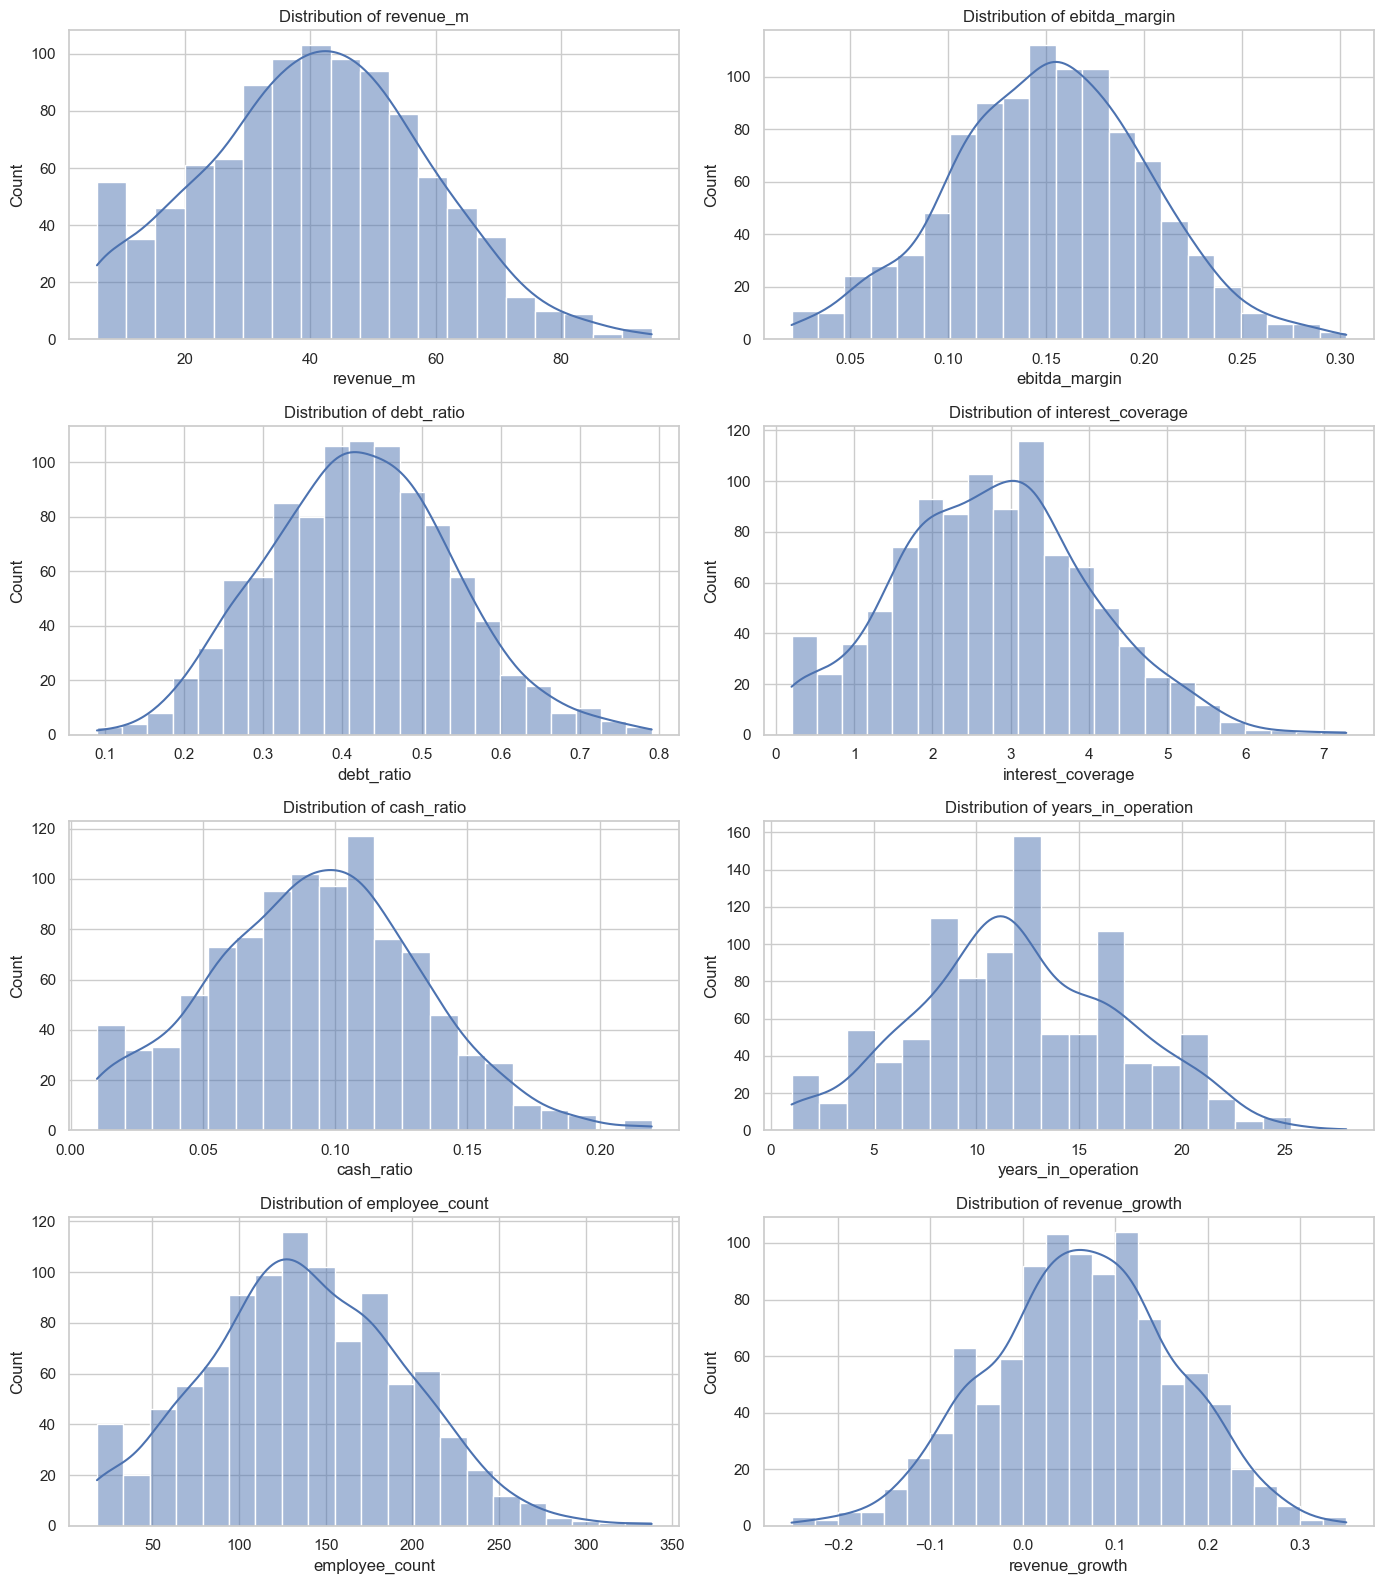

In [6]:
nrows = (len(num_cols) + 1) // 2
fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(14, nrows * 4))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


## Outlier Detection (Boxplots)


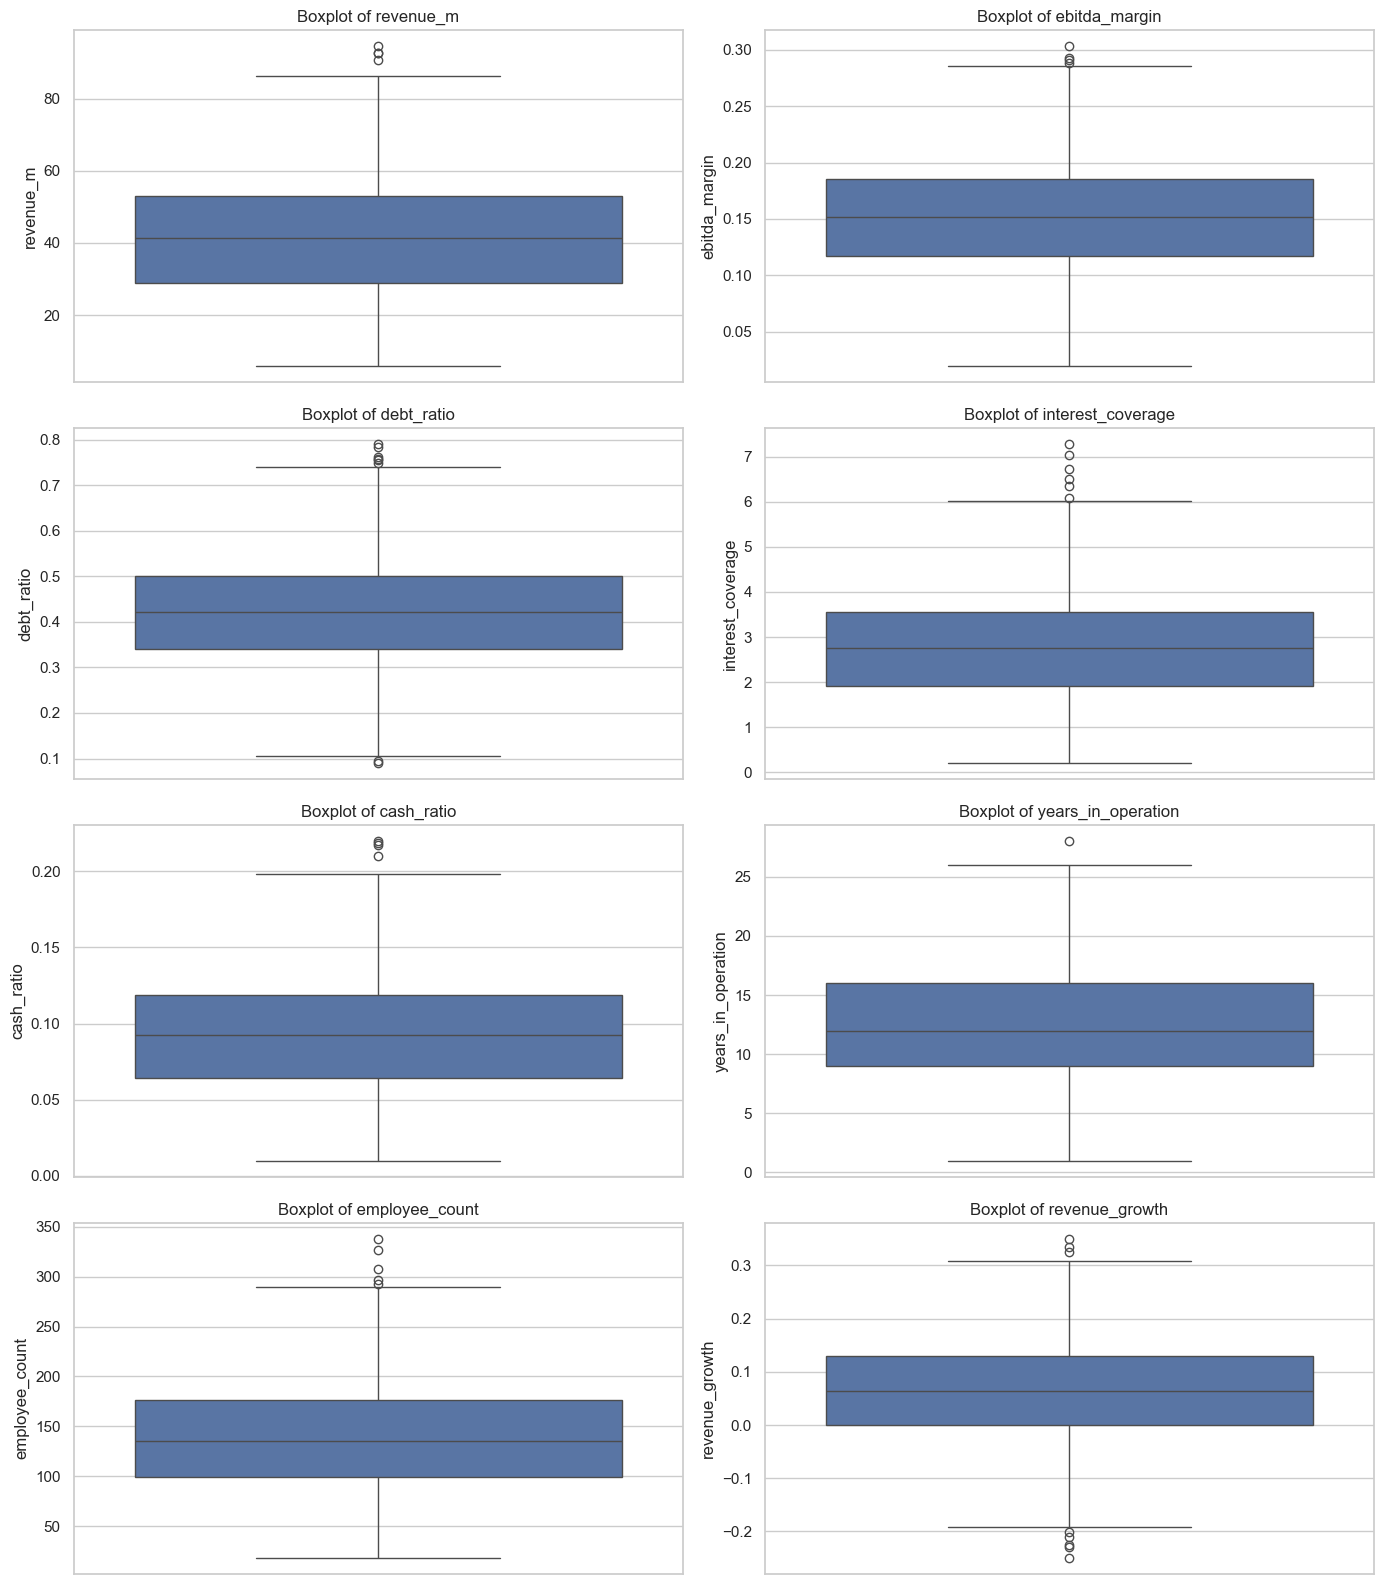

In [7]:
fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(14, nrows * 4))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


## Categorical Features Analysis



Value counts for sector:
sector
Manufacturing              116
Logistics                  115
Hospitality                108
Renewable Energy           105
Consumer Finance           103
Real Estate                100
Retail                      97
Crypto / Digital Assets     93
Software                    86
Healthcare                  77
Name: count, dtype: int64


C:\Users\pedre\AppData\Local\Temp\ipykernel_14488\647871453.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')


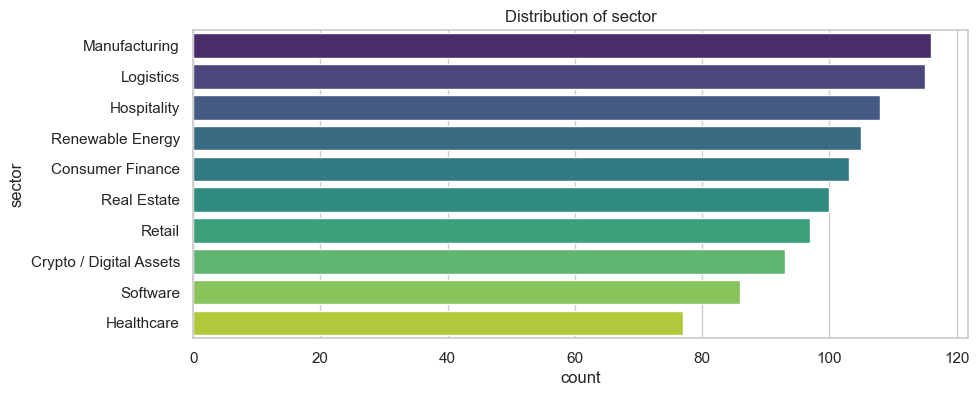


Value counts for country:
country
UK             130
Ireland        127
Spain          127
France         127
Luxembourg     126
Italy          126
Germany        124
Netherlands    113
Name: count, dtype: int64


C:\Users\pedre\AppData\Local\Temp\ipykernel_14488\647871453.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')


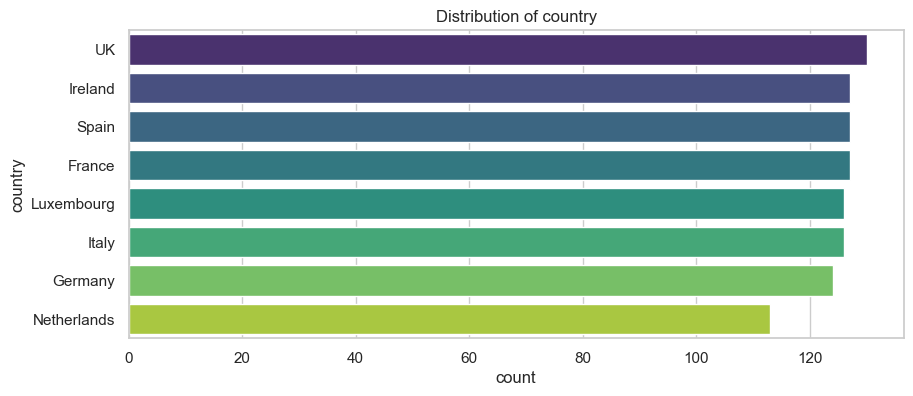

In [8]:
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
if 'company_name' in cat_cols: cat_cols.remove('company_name')
if 'company_id' in cat_cols: cat_cols.remove('company_id')
for col in cat_cols:
    print(f'\nValue counts for {col}:')
    print(df[col].value_counts())
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.show()


## Correlation Analysis


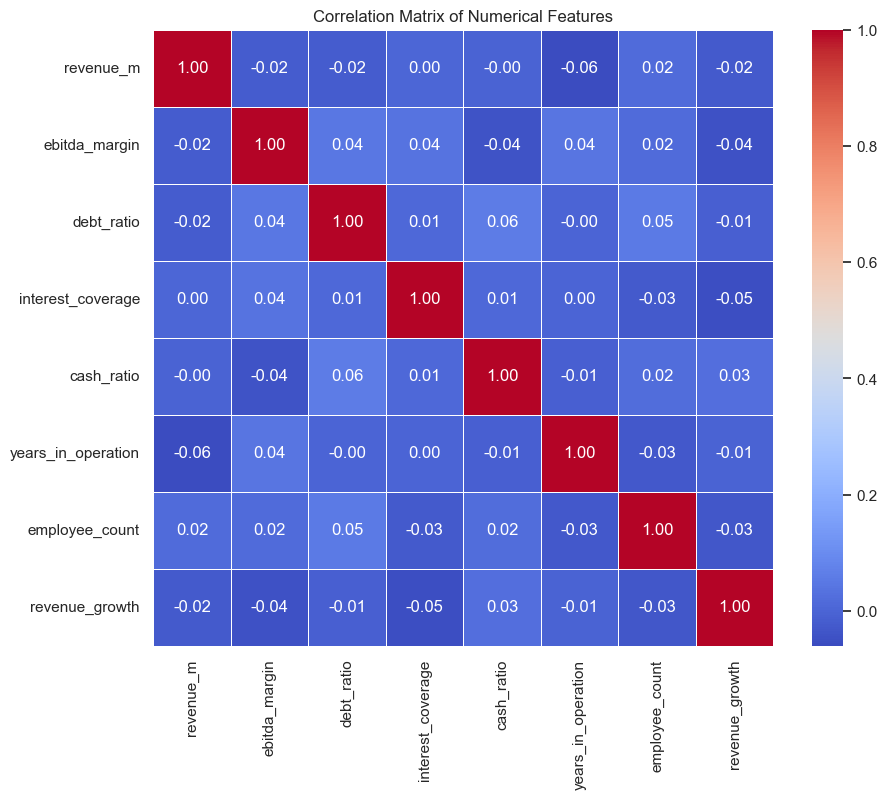

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()
